In [6]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy.abc import x, y, s

# a_coeffs = ["3.4/(exp(s)+exp(-s))","-0.5*s**2+1.2",0.3,0.5]
# b_coeffs = ["2*exp(-s**2)",0.5,"1/(1+s**2)**1.5",0.05]
a_coeffs = ["1.2-0.3*s", "1-s**2", 0.02, 0.002]
b_coeffs = ["1-s**4",0.1,0.4, "0.5-0.4*s**2"]
nphi=6

In [17]:
expansion = bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs, nphi=nphi)
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func) with lambdify=False
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_num = Bx_func(X, Y, S)
By_num = By_func(X, Y, S)
Bs_num = Bs_func(X, Y, S)
#print("Bx shape:", Bx_num.shape, "By shape:", By_num.shape, "Bs shape:", Bs_num.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_num.ravel(),
    By_num.ravel(),
    Bs_num.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)

In [42]:
# Choose a fixed s value (e.g., s=0 for the magnet center)
s_fixed = 0.22

bnian=fm.harmonic_analysis_at_s(spos=s_fixed, rmin=0.02, rmax=0.8, nr=50, ntheta=256, radius=0.03)
bn=bnian.real[:len(b_coeffs)]
an=bnian.imag[:len(a_coeffs)]

In [43]:
import sympy
#evaluate the original coefficients at s=s_fixed
a_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in a_coeffs]
b_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in b_coeffs]
print("Harmonic analysis results at s=", s_fixed)
print("recovered bn(s=",s_fixed,"):", bn)
print("Original b_coeffs(s):", b_coeffs_eval)
print("recovered an(s=",s_fixed,"):", an)
print("Original a_coeffs(s):", a_coeffs_eval)

Harmonic analysis results at s= 0.22
recovered bn(s= 0.22 ): [0.99765926 0.1003627  0.40089992 1.55568102]
Original b_coeffs(s): [0.997657440000000, 0.100000000000000, 0.400000000000000, 0.480640000000000]
recovered an(s= 0.22 ): [ 1.134       0.95505795  0.0200639  10.1274    ]
Original a_coeffs(s): [1.13400000000000, 0.951600000000000, 0.0200000000000000, 0.00200000000000000]


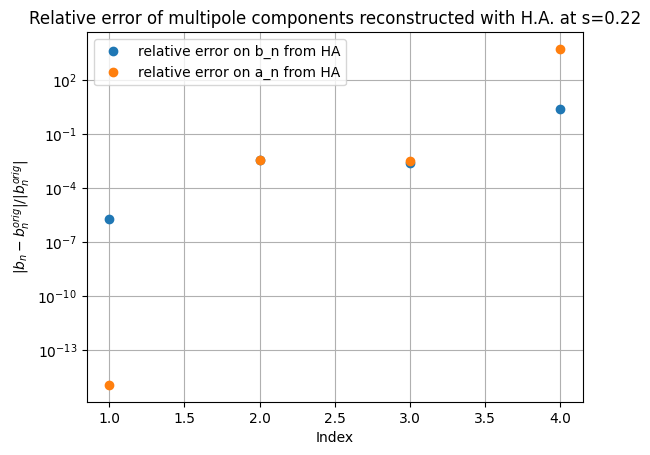

In [ ]:
#plt.plot(range(1,len(a_coeffs)+1), (a_coeffs_eval-an)/a_coeffs_eval, 'o', label='relative error on a_n $(a_n - a_nnew)/a_n$')
plt.xlabel('Index')
plt.ylabel('Relative error')
plt.plot(range(1,len(b_coeffs)+1), abs(b_coeffs_eval-bn)/b_coeffs_eval, 'o', label='relative error on b_n from HA')
plt.plot(range(1,len(a_coeffs)+1), abs(a_coeffs_eval-an)/a_coeffs_eval, 'o', label='relative error on a_n from HA')
plt.legend()
plt.yscale("log")
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.grid(True)
plt.show()

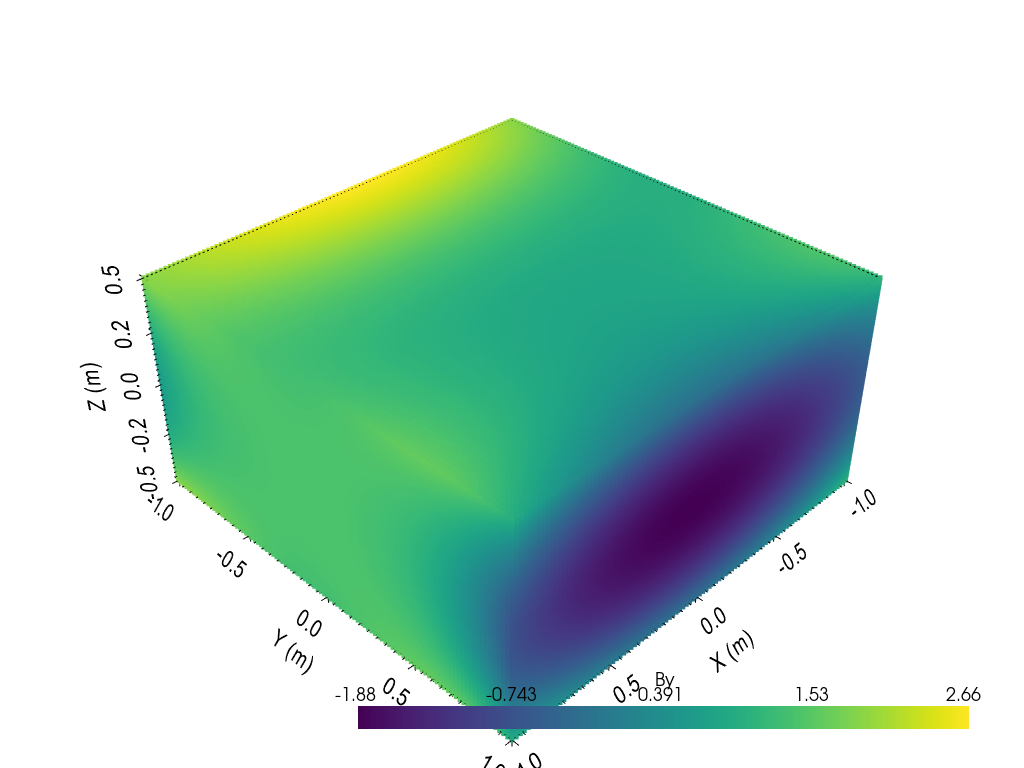

In [45]:
#make a fieldmap object
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-0.5,0.5,101)
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
fm.plot()

Harmonic analysis along the s axis

In [46]:
sv, recbn, stdrecbn = fm.s_harmonics(order=4, rmin=0.02, rmax=0.8, nr=50, radius=0.03)

In [27]:
#evaluate the original coefficients along an s axis array
a_coeffs_eval_along_s = np.array([[sympy.sympify(coeff).subs(s, s_val) for coeff in a_coeffs] for s_val in sv])
b_coeffs_eval_along_s = np.array([[sympy.sympify(coeff).subs(s, s_val) for coeff in b_coeffs] for s_val in sv])

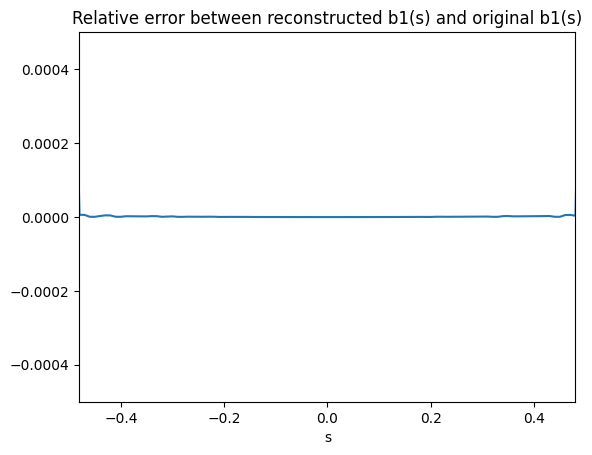

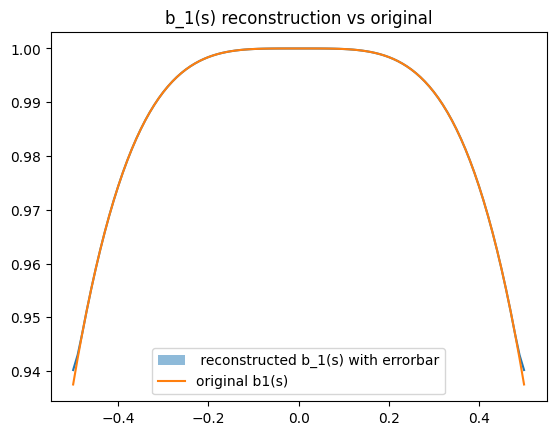

In [28]:
plt.plot(sv, (recbn[:,0]-b_coeffs_eval_along_s[:,0])/b_coeffs_eval_along_s[:,0])
plt.title('Relative error between reconstructed b1(s) and original b1(s)')
plt.xlabel('s')
plt.xlim((-0.48,0.48))
plt.ylim((-0.0005,0.0005))
plt.show()
plt.plot(sv, recbn[:,0])
plt.fill_between(sv, recbn[:,0]-stdrecbn[:,0], recbn[:,0]+stdrecbn[:,0], alpha=0.5, label=" reconstructed b_1(s) with errorbar")
plt.plot(sv, b_coeffs_eval_along_s[:,0], label="original b1(s)")
plt.legend()
plt.title("b_1(s) reconstruction vs original")
plt.show()


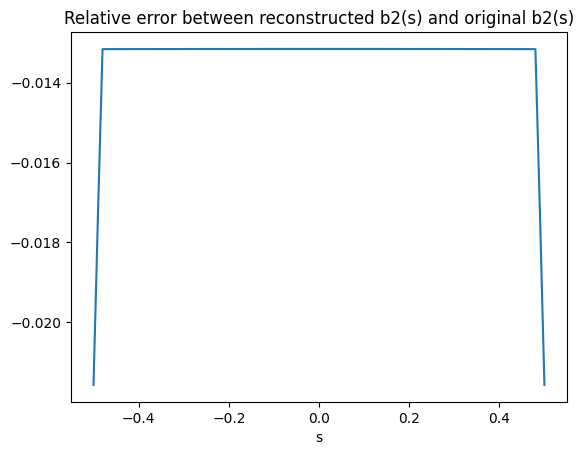

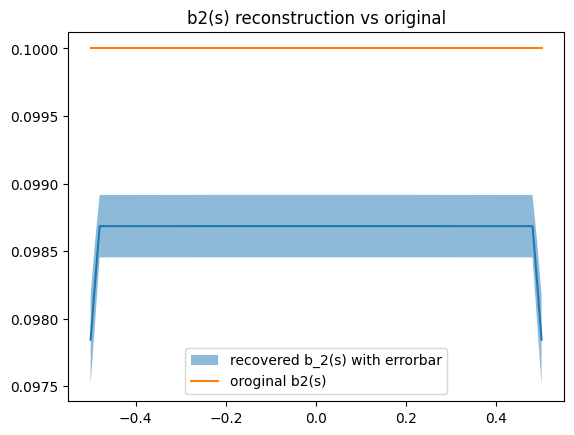

In [29]:
plt.plot(sv, (recbn[:,1]-b_coeffs_eval_along_s[:,1])/(b_coeffs_eval_along_s[:,1]))
plt.title('Relative error between reconstructed b2(s) and original b2(s)')

plt.xlabel('s')
plt.show()
plt.plot(sv, recbn[:,1])
plt.fill_between(sv, recbn[:,1]-stdrecbn[:,1], recbn[:,1]+stdrecbn[:,1], alpha=0.5, label="recovered b_2(s) with errorbar")
plt.plot(sv, b_coeffs_eval_along_s[:,1], label="oroginal b2(s)")
plt.title("b2(s) reconstruction vs original")
plt.legend()
plt.show()
